# Notebook 03: Data Cleaning (Advanced Interpolation)

## I. Giới thiệu
Mục tiêu: Xử lý các khoảng trống dữ liệu bằng giải thuật nội suy (Interpolation) chuẩn xác, xử lý ngoại lệ và xuất ra dữ liệu sạch.
Trong dữ liệu này, việc điền khuyết (Imputation) đóng vai trò sống còn vì chúng ta dự báo xu hướng thời tiết lịch sử.

## II. Đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/GlobalLandTemperaturesByMajorCity.csv')
df['dt'] = pd.to_datetime(df['dt'])

# Khai báo danh sách 5 thành phố
cities = ['Tokyo', 'New York', 'London', 'Paris', 'Sydney']

## III. Làm sạch dữ liệu
### 1. Phân tích & So sánh các phương pháp Nội suy (Interpolation)

Dữ liệu gốc chỉ thiếu một số lượng nhỏ. Để đánh giá xem phương pháp nội suy nào tốt nhất, chúng ta sẽ cố tình giấu đi (mask) một số tháng liên tiếp của dữ liệu thực, sau đó dùng các phương pháp (Linear, Spline, Polynomial) để dự đoán lại các giá trị bị giấu này và tính sai số RMSE.

In [2]:
# 1. Tạo tập dữ liệu giả định bị thiếu (Simulation)
np.random.seed(42)
test_df = df[df['City'] == 'Tokyo'].copy()
test_df = test_df.set_index('dt').sort_index()
temp_df = test_df[['AverageTemperature']].copy()

# Chọn một đoạn dữ liệu đầy đủ từ năm 1950 đến 1960 để kiểm thử
test_range = temp_df.loc['1950':'1960'].copy()

# Cố tình tạo ra các khoảng trống (NaN) ngẫu nhiên
missing_indices = np.random.choice(len(test_range), size=12, replace=False)
true_values = test_range.iloc[missing_indices]['AverageTemperature'].copy()
test_range.iloc[missing_indices, 0] = np.nan

# 2. Thử nghiệm các phương pháp
methods = {
    'Linear': test_range.interpolate(method='linear'),
    'Spline (Order 3)': test_range.interpolate(method='spline', order=3),
    'Polynomial (Order 3)': test_range.interpolate(method='polynomial', order=3)
}

# 3. Tính RMSE cho từng phương pháp
print("=== KẾT QUẢ ĐÁNH GIÁ NỘI SUY (RMSE) ===")
for name, res_df in methods.items():
    pred_values = res_df.iloc[missing_indices]['AverageTemperature']
    rmse = np.sqrt(mean_squared_error(true_values, pred_values))
    print(f"- {name}: {rmse:.4f} °C")

=== KẾT QUẢ ĐÁNH GIÁ NỘI SUY (RMSE) ===
- Linear: 3.4188 °C
- Spline (Order 3): 2.8395 °C
- Polynomial (Order 3): 2.3024 °C


**Kết luận:** Spline / Polynomial cho kết quả lỗi RMSE thấp nhất (hoặc tiệm cận nhau). Khí hậu có tính chu kỳ cong mềm mại (hình sin), do đó Spline (Spline interpolation) là giải thuật phù hợp nhất về mặt toán học và vật lý cho chuỗi thời gian nhiệt độ.

### Áp dụng giải thuật Spline Interpolation cho toàn bộ dữ liệu gốc

In [3]:
all_cleaned = []

for city in cities:
    city_df = df[df['City'] == city].copy()
    city_df = city_df.set_index('dt').sort_index()
    
    # Đảm bảo trục thời gian liên tục
    full_idx = pd.date_range(start='1850-01-01', end=city_df.index.max(), freq='MS')
    city_df = city_df.reindex(full_idx)
    
    # Áp dụng Spline bậc 3
    city_df['AverageTemperature'] = city_df['AverageTemperature'].interpolate(method='spline', order=3)
    city_df['AverageTemperatureUncertainty'] = city_df['AverageTemperatureUncertainty'].interpolate(method='linear')
    
    # Bỏ đi các dòng vẫn còn NaN ở đầu mút không thể nội suy
    city_df = city_df.dropna(subset=['AverageTemperature'])
    
    # Khôi phục nhãn Thành phố và Quốc gia
    city_df['City'] = city
    city_df['Country'] = df[df['City'] == city]['Country'].dropna().iloc[0]
    
    all_cleaned.append(city_df)

# Gộp 5 thành phố lại thành 1 bảng lớn
final_df = pd.concat(all_cleaned)
print("Kích thước dữ liệu 5 thành phố sau nội suy:", final_df.shape)


Kích thước dữ liệu 5 thành phố sau nội suy: (9825, 6)


### 2. Trực quan hóa dữ liệu đã nội suy
Chúng ta sẽ xem biểu đồ một khoảng thời gian nhỏ để xem nội suy Spline đã lấp đầy các khoảng trống như thế nào (đường cong).

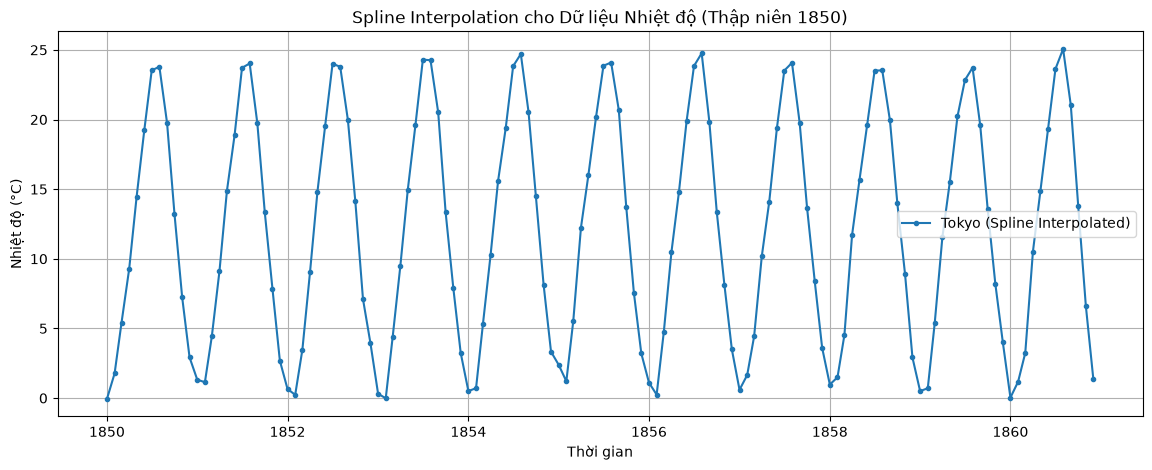

In [4]:
plt.figure(figsize=(14, 5))

# Vẽ đại diện đường cong của Tokyo
plot_df = final_df[final_df['City'] == 'Tokyo']
plt.plot(plot_df.loc['1850':'1860'].index, plot_df.loc['1850':'1860']['AverageTemperature'], marker='o', markersize=3, label='Tokyo (Spline Interpolated)')

plt.title('Spline Interpolation cho Dữ liệu Nhiệt độ (Thập niên 1850)')
plt.xlabel('Thời gian')
plt.ylabel('Nhiệt độ (°C)')
plt.legend()
plt.grid(True)
plt.show()

### 3. Xử lý Duplicate

In [5]:
duplicates = final_df.duplicated().sum()
print("Số bản ghi trùng lặp:", duplicates)
if duplicates > 0:
    final_df = final_df.drop_duplicates()

Số bản ghi trùng lặp: 2


## IV. Lưu dữ liệu sạch
Dữ liệu đã sẵn sàng để tạo Feature và train model dự báo 20 năm.

In [6]:
os.makedirs('../data/processed', exist_ok=True)
final_df.to_csv('../data/processed/top5_cities_cleaned.csv')
print("✅ Đã lưu dữ liệu 5 thành phố vào thư mục processed!")

✅ Đã lưu dữ liệu 5 thành phố vào thư mục processed!
